🧩 Week 19 · Day 1 — Compute & Parallelization Basics (CPU-Only)
Why this matters

Modern AI models depend on efficient computation. Even if you train on a CPU, you can still understand how parallelization, batch size, and precision affect speed — all key to scaling later.

🧠 Theory Essentials

Parallelism types:

Data parallelism → split dataset across devices or workers.

Model parallelism → split model layers across devices.

Pipeline parallelism → split the forward pass into stages.

CPU vs GPU vs TPU:
CPUs handle general tasks sequentially; GPUs excel at parallel math; TPUs are specialized AI hardware.

Batch size: affects memory and throughput; bigger batches = fewer updates per epoch.

Gradient accumulation: allows simulating large batches without extra memory.

DataLoader workers: even on CPU, multiple workers load batches in parallel.

Throughput: number of samples processed per second — your key benchmark.

Device: cpu
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 7364624.09it/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 310364.81it/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2090860.56it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 1447938.65it/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



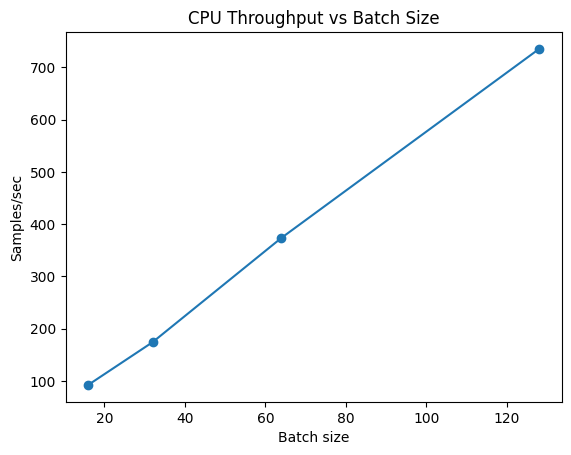

In [1]:
# Setup
import torch, time, matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim

torch.set_num_threads(4)  # use CPU parallel threads

device = torch.device("cpu")
print("Device:", device)

# Simple CNN
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*14*14, 10)
        )
    def forward(self, x): return self.net(x)

# Data
transform = transforms.Compose([transforms.ToTensor()])
train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Benchmark function
def benchmark(batch_size, num_workers):
    loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    model = SmallCNN().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    start = time.time()
    for i, (x, y) in enumerate(loader):
        if i == 50: break  # fewer iterations for CPU
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward(); opt.step()
    return time.time() - start

# Run benchmarks
batch_sizes = [16, 32, 64, 128]
times = [benchmark(b, num_workers=2) for b in batch_sizes]
throughputs = [b*50 / t for b, t in zip(batch_sizes, times)]

plt.plot(batch_sizes, throughputs, marker="o")
plt.title("CPU Throughput vs Batch Size")
plt.xlabel("Batch size"); plt.ylabel("Samples/sec")
plt.show()


1) Core (10–15 min)
Task: Change num_workers from 0 → 2 → 4 → 8 and measure speed.

Device: cpu


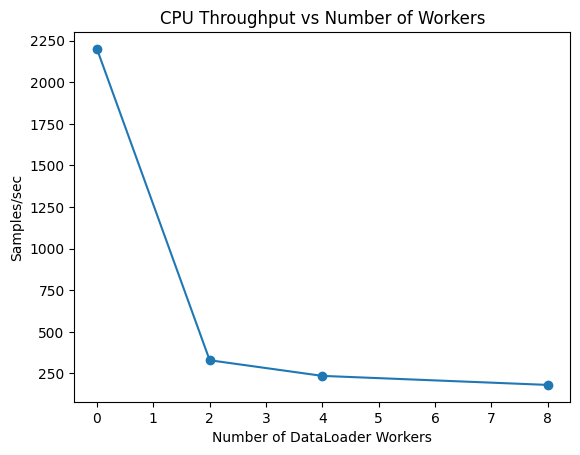

In [3]:
# Setup
import torch, time, matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim

torch.set_num_threads(4)  # limit CPU threads

device = torch.device("cpu")
print("Device:", device)

# Simple CNN
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*14*14, 10)
        )
    def forward(self, x): 
        return self.net(x)

# Data
transform = transforms.Compose([transforms.ToTensor()])
train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Benchmark function
def benchmark(num_workers, batch_size=64):
    loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    model = SmallCNN().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    start = time.time()
    for i, (x, y) in enumerate(loader):
        if i == 50: break  # fewer iterations for CPU
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward(); opt.step()
    return time.time() - start

# Run benchmarks
num_workers_list = [0, 2, 4, 8]
times = [benchmark(w) for w in num_workers_list]
throughputs = [64 * 50 / t for t in times]  # batch_size * steps / total_time

# Plot
plt.plot(num_workers_list, throughputs, marker="o")
plt.title("CPU Throughput vs Number of Workers")
plt.xlabel("Number of DataLoader Workers")
plt.ylabel("Samples/sec")
plt.show()


More workers load data in parallel, but too many can slow down.

2) Practice (10–15 min)
Task: Try torch.set_num_threads() = 1, 2, 4, 8 and compare times.

🔍 What torch.set_num_threads() does

It controls how many CPU threads PyTorch can use for intra-operation parallelism — meaning how many threads are used inside a single operation like matrix multiplication or convolution.

So:

torch.set_num_threads(1) → all operations run sequentially.

torch.set_num_threads(8) → PyTorch can split work across 8 CPU cores for the same operation.

This is different from num_workers in the DataLoader, which controls how many separate processes load data in parallel.
👉 In short:

num_workers = parallel data loading.

set_num_threads() = parallel computation.

Device: cpu


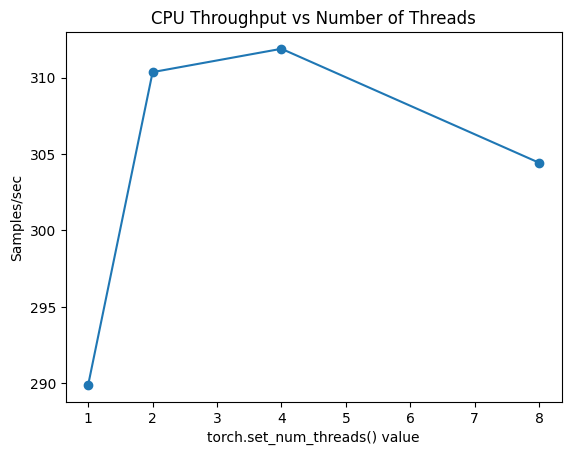

In [4]:
# Setup
import torch, time, matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim

device = torch.device("cpu")
print("Device:", device)

# Simple CNN
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*14*14, 10)
        )
    def forward(self, x): 
        return self.net(x)

# Data
transform = transforms.Compose([transforms.ToTensor()])
train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Benchmark function
def benchmark(num_threads):
    torch.set_num_threads(num_threads)
    loader = torch.utils.data.DataLoader(train, batch_size=64, shuffle=True, num_workers=2)
    model = SmallCNN().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    start = time.time()
    for i, (x, y) in enumerate(loader):
        if i == 50: break
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward(); opt.step()
    return time.time() - start

# Run benchmarks
thread_counts = [1, 2, 4, 8]
times = [benchmark(t) for t in thread_counts]
throughputs = [64 * 50 / t for t in times]

# Plot
plt.plot(thread_counts, throughputs, marker="o")
plt.title("CPU Throughput vs Number of Threads")
plt.xlabel("torch.set_num_threads() value")
plt.ylabel("Samples/sec")
plt.show()


3) Stretch (optional)
Task: Simulate “gradient accumulation.” Process 2 mini-batches before optimizer step.

In [5]:
# Gradient accumulation example
import torch, time
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim

device = torch.device("cpu")

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*14*14, 10)
        )
    def forward(self, x): 
        return self.net(x)

# Data
transform = transforms.Compose([transforms.ToTensor()])
train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(train, batch_size=64, shuffle=True, num_workers=2)

# Model & optimizer
model = SmallCNN().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

accum_steps = 2  # number of mini-batches to accumulate
start = time.time()

for i, (x, y) in enumerate(loader):
    if i == 100: break
    loss = loss_fn(model(x), y)
    loss.backward()  # accumulate gradients
    
    # Only update every 'accum_steps' iterations
    if (i + 1) % accum_steps == 0:
        opt.step()
        opt.zero_grad()

print("Finished training in %.2fs" % (time.time() - start))


Finished training in 10.50s


🚀 Mini-Challenge (≤40 min)

Goal: Build a CPU efficiency report showing how batch size, workers, and threads affect performance.

Acceptance Criteria:

Table with columns: batch_size, num_workers, threads, samples/sec.

One line plot per variable.

Short paragraph: what parameter gives the best CPU efficiency and why.

Device: cpu
Top 5 configurations by throughput:
 batch_size  num_workers  threads  samples_per_sec
         32            0        4      2376.557165
         32            0        2      2335.246192
         64            0        8      2096.351732
         32            0        1      1941.293583
         64            0        4      1922.360312


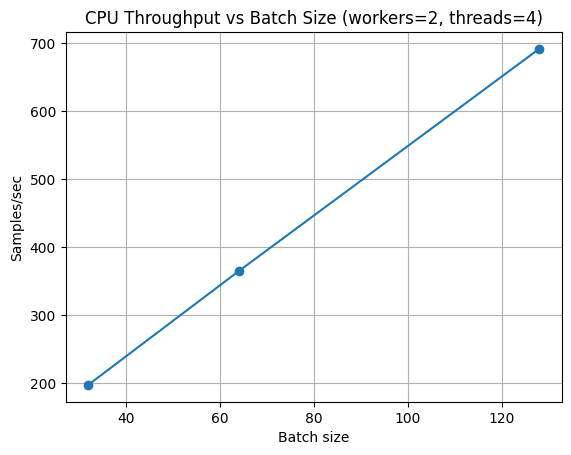

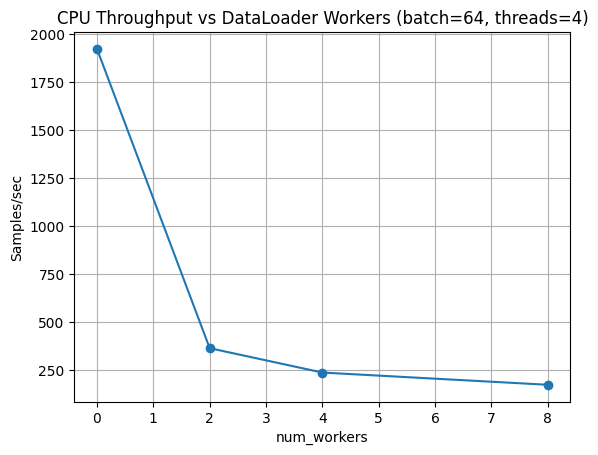

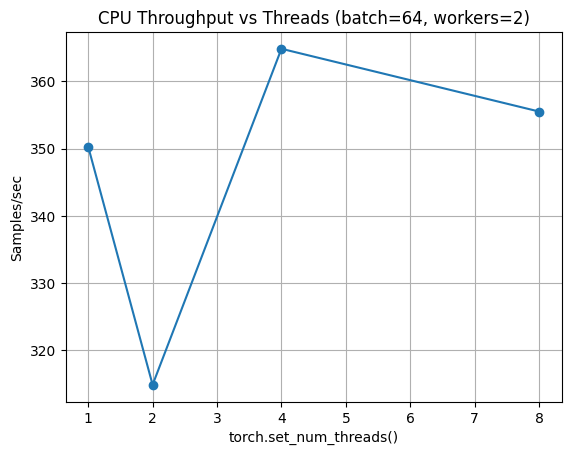


Full results table (batch_size, num_workers, threads, samples/sec):
 batch_size  num_workers  threads  samples_per_sec
         32            0        4      2376.557165
         32            0        2      2335.246192
         64            0        8      2096.351732
         32            0        1      1941.293583
         64            0        4      1922.360312
         32            0        8      1815.815068
         64            0        2      1619.125597
        128            0        4      1474.085632
         64            0        1      1406.167477
        128            0        8      1322.411892
        128            0        2      1200.880899
        128            0        1       831.996138
        128            2        4       691.535628
        128            2        2       612.080862
        128            2        8       611.621087
        128            2        1       537.023049
        128            4        4       515.999953
        128  

In [6]:
# CPU Efficiency Mini-Challenge — Batch Size, DataLoader Workers, Threads
import time, math, itertools
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from torchvision import datasets, transforms

# -----------------------------
# Setup
# -----------------------------
device = torch.device("cpu")
print("Device:", device)

# Simple CNN kept tiny for quick CPU runs
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*14*14, 10)
        )
    def forward(self, x): return self.net(x)

# Data (MNIST)
transform = transforms.Compose([transforms.ToTensor()])
train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

def benchmark(batch_size: int, num_workers: int, threads: int, steps: int = 50) -> float:
    """
    Returns throughput (samples/sec) for the given settings.
    """
    torch.set_num_threads(threads)  # compute parallelism inside ops
    loader = torch.utils.data.DataLoader(
        train, batch_size=batch_size, shuffle=True, num_workers=num_workers
    )
    model = SmallCNN().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    # --- timed run ---
    start = time.perf_counter()
    for i, (x, y) in enumerate(loader):
        if i == steps: break
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()
    elapsed = time.perf_counter() - start

    return (batch_size * steps) / elapsed  # samples/sec

# -----------------------------
# Grid to evaluate
# -----------------------------
batch_sizes    = [32, 64, 128]
num_workers_ls = [0, 2, 4, 8]
thread_counts  = [1, 2, 4, 8]

rows = []
for b, w, t in itertools.product(batch_sizes, num_workers_ls, thread_counts):
    thr = benchmark(b, w, t, steps=50)
    rows.append({"batch_size": b, "num_workers": w, "threads": t, "samples_per_sec": thr})

df = pd.DataFrame(rows).sort_values("samples_per_sec", ascending=False).reset_index(drop=True)
print("Top 5 configurations by throughput:")
print(df.head(5).to_string(index=False))

# -----------------------------
# Plots: one line plot per variable (fix the others)
# -----------------------------
# Choose middle/fair fixed values that exist in the grid
FIX_WORKERS = 2
FIX_THREADS = 4
FIX_BATCH   = 64

# 1) Throughput vs Batch Size (fix workers & threads)
plot1 = df[(df["num_workers"] == FIX_WORKERS) & (df["threads"] == FIX_THREADS)]
plot1 = plot1.sort_values("batch_size")
plt.figure()
plt.plot(plot1["batch_size"], plot1["samples_per_sec"], marker="o")
plt.title(f"CPU Throughput vs Batch Size (workers={FIX_WORKERS}, threads={FIX_THREADS})")
plt.xlabel("Batch size"); plt.ylabel("Samples/sec")
plt.grid(True)
plt.show()

# 2) Throughput vs Number of Workers (fix batch & threads)
plot2 = df[(df["batch_size"] == FIX_BATCH) & (df["threads"] == FIX_THREADS)]
plot2 = plot2.sort_values("num_workers")
plt.figure()
plt.plot(plot2["num_workers"], plot2["samples_per_sec"], marker="o")
plt.title(f"CPU Throughput vs DataLoader Workers (batch={FIX_BATCH}, threads={FIX_THREADS})")
plt.xlabel("num_workers"); plt.ylabel("Samples/sec")
plt.grid(True)
plt.show()

# 3) Throughput vs Threads (fix batch & workers)
plot3 = df[(df["batch_size"] == FIX_BATCH) & (df["num_workers"] == FIX_WORKERS)]
plot3 = plot3.sort_values("threads")
plt.figure()
plt.plot(plot3["threads"], plot3["samples_per_sec"], marker="o")
plt.title(f"CPU Throughput vs Threads (batch={FIX_BATCH}, workers={FIX_WORKERS})")
plt.xlabel("torch.set_num_threads()"); plt.ylabel("Samples/sec")
plt.grid(True)
plt.show()

# -----------------------------
# Final table (acceptance criteria)
# -----------------------------
print("\nFull results table (batch_size, num_workers, threads, samples/sec):")
print(df.to_string(index=False))


🧭 Notes / Key Takeaways

Even on CPU, parallelism matters: use multiple workers & threads.

Throughput increases with batch size but saturates due to memory/cache limits.

Gradient accumulation can help when memory is low.

Benchmarking teaches how hardware and code interact.

Efficient data loading = faster training.

💬 Reflection

Which factor — batch size, workers, or threads — gave the largest speedup?

What hardware limits might prevent scaling further?

-Threads, workers and batch size gave speedups

-Hardware limits like the number of physical CPU cores, memory bandwidth, and disk I/O can prevent further scaling. Once all cores are busy, adding more threads or workers only adds scheduling overhead. Also, data loading can become bottlenecked by storage speed or RAM access rather than compute power.